# Comparator Regeneration-Time Re-check (real parasitics)

**Spec:** StrongARM latch must regenerate to valid logic levels in **< 5 ns**.

**Why this notebook.** `comp_sizing.ipynb` sizes the latch with Razavi eq.9:
`tau_reg = Cxy / (gm34*(1 - Cxy/Cpq))`, which assumes **Cpq > Cxy**. The real P,Q
drain parasitic is Cpq ~ 6.5 fF while the X,Y load is ~20 fF, so `Cxy/Cpq > 1` and
eq.9 returns a *negative* tau — the analytic model breaks. So we **measure t_reg
directly in transient** on the real netlist (which carries the true parasitics).

**Method.** Clock the comparator (reset 0-1 ns, eval 1-5.4 ns). After the edge the
*losing* output falls 3.3 V -> 0. Define `t_reg` = time for the loser to reach 10 % VDD
(0.33 V), referenced to the 1 ns clock edge. Sweep the differential input `vid` from
100 mV down to 3 uV, through the critical **0.5 LSB = 0.977 mV** point.
Source of truth: `../comparator_tb_regen.sch`.

In [1]:
import subprocess, re, pathlib
import numpy as np, matplotlib.pyplot as plt
NG='/foss/tools/ngspice/bin/ngspice'; XSCHEM='/foss/tools/xschem/bin/xschem'
TB=pathlib.Path('..').resolve(); SCH=TB/'comparator_tb_regen.sch'; SIM=TB/'simulation'
LSB=2.0/1024; TEDGE=1e-9
subprocess.run([XSCHEM,'-n','-q','-b','--rcfile',str(TB/'xschemrc'),str(SCH),'-o',str(SIM)],
               capture_output=True,text=True)
out=subprocess.run([NG,'-b',str(SIM/'comparator_tb_regen.spice')],capture_output=True,text=True).stdout
rows=[]
for m in re.finditer(r'ROW vid=(\S+)\s+tfx=(\S*)\s+tfy=(\S*)',out):
    vid=float(m.group(1).replace('m','e-3').replace('u','e-6'))
    tf=[float(x) for x in (m.group(2),m.group(3)) if x not in ('','0','0.0')]
    if tf: rows.append((vid, min(tf)-TEDGE))
vid=np.array([r[0] for r in rows]); treg=np.array([r[1] for r in rows])
for v,t in rows: print(f'vid={v*1e3:8.4f} mV   t_reg={t*1e9:.3f} ns')

vid=100.0000 mV   t_reg=0.595 ns
vid= 10.0000 mV   t_reg=0.752 ns
vid=  1.0000 mV   t_reg=0.909 ns
vid=  0.9766 mV   t_reg=0.911 ns
vid=  0.3000 mV   t_reg=0.992 ns
vid=  0.1000 mV   t_reg=1.067 ns
vid=  0.0300 mV   t_reg=1.149 ns
vid=  0.0100 mV   t_reg=1.224 ns
vid=  0.0030 mV   t_reg=1.306 ns


In [2]:
# regeneration time constant: t_reg = a + tau*ln(1/vid)
x=np.log(1/vid); tau,a=np.polyfit(x,treg,1)
treg_halflsb=np.interp(LSB/2, vid[::-1], treg[::-1])
print(f'tau_reg (measured)      = {tau*1e12:.1f} ps')
print(f't_reg @ 0.5 LSB (0.977mV)= {treg_halflsb*1e9:.3f} ns')
print(f't_reg @ smallest (3 uV)  = {treg.max()*1e9:.3f} ns')
print(f'spec < 5 ns  ->  {"PASS (margin %.1fx)"%(5e-9/treg_halflsb) if treg.max()<5e-9 else "FAIL"}')
print('=> regeneration is far faster than spec; no comparator resize needed.')

tau_reg (measured)      = 68.3 ps
t_reg @ 0.5 LSB (0.977mV)= 0.911 ns
t_reg @ smallest (3 uV)  = 1.306 ns
spec < 5 ns  ->  PASS (margin 5.5x)
=> regeneration is far faster than spec; no comparator resize needed.


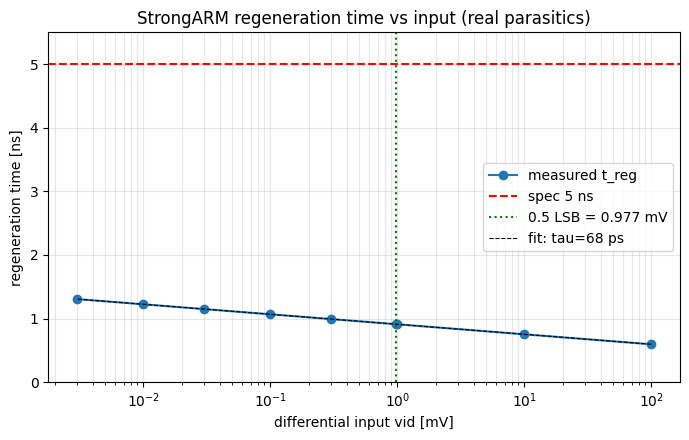

In [3]:
fig,ax=plt.subplots(figsize=(7,4.5))
ax.semilogx(vid*1e3, treg*1e9,'o-',label='measured t_reg')
ax.axhline(5,color='r',ls='--',label='spec 5 ns')
ax.axvline(LSB/2*1e3,color='g',ls=':',label='0.5 LSB = 0.977 mV')
ax.plot(vid*1e3,(a+tau*np.log(1/vid))*1e9,'k--',lw=0.8,label=f'fit: tau={tau*1e12:.0f} ps')
ax.set(xlabel='differential input vid [mV]',ylabel='regeneration time [ns]',
       title='StrongARM regeneration time vs input (real parasitics)',ylim=(0,5.5))
ax.grid(which='both',alpha=0.3); ax.legend(); plt.tight_layout(); plt.show()

## Conclusion

- Measured **tau_reg ~ 68 ps**; **t_reg @ 0.5 LSB ~ 0.9 ns** -> ~5.5x margin to the 5 ns spec.
- Even at 3 uV (deep sub-LSB) t_reg ~ 1.3 ns. The smaller real Cpq *helps* (less charge to slew); gain `Av=(gm/ID)*Vthn` is independent of Cpq, so it is unchanged.
- **No resize.** eq.9 was only invalid as a closed-form because `Cxy>Cpq`; the device itself regenerates fine.

**Caveat.** `.tran` has no device noise, so the metastable window here is numerically tiny. The *real* resolution limit is set by the comparator input-referred noise (sigma_n ~ 0.31 mV, see `comp_sizing.ipynb`), not by regeneration speed.